In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Preparation for reading data from csv file on Google Colab
# remove when reading the csv file locally from your computer
import os
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/HS/Intern/07_Ind_Prod_Util')

Mounted at /content/drive


In [7]:
df = pd.read_csv("IPG2211A2N.csv")

In [8]:
# Convert 'observation_date' to datetime and set as index
df['observation_date'] = pd.to_datetime(df['observation_date'])
df = df.set_index('observation_date')
df.head(3)

,IPG2211A2N
observation_date,
1939-01-01,3.3336
1939-02-01,3.3591
1939-03-01,3.4354


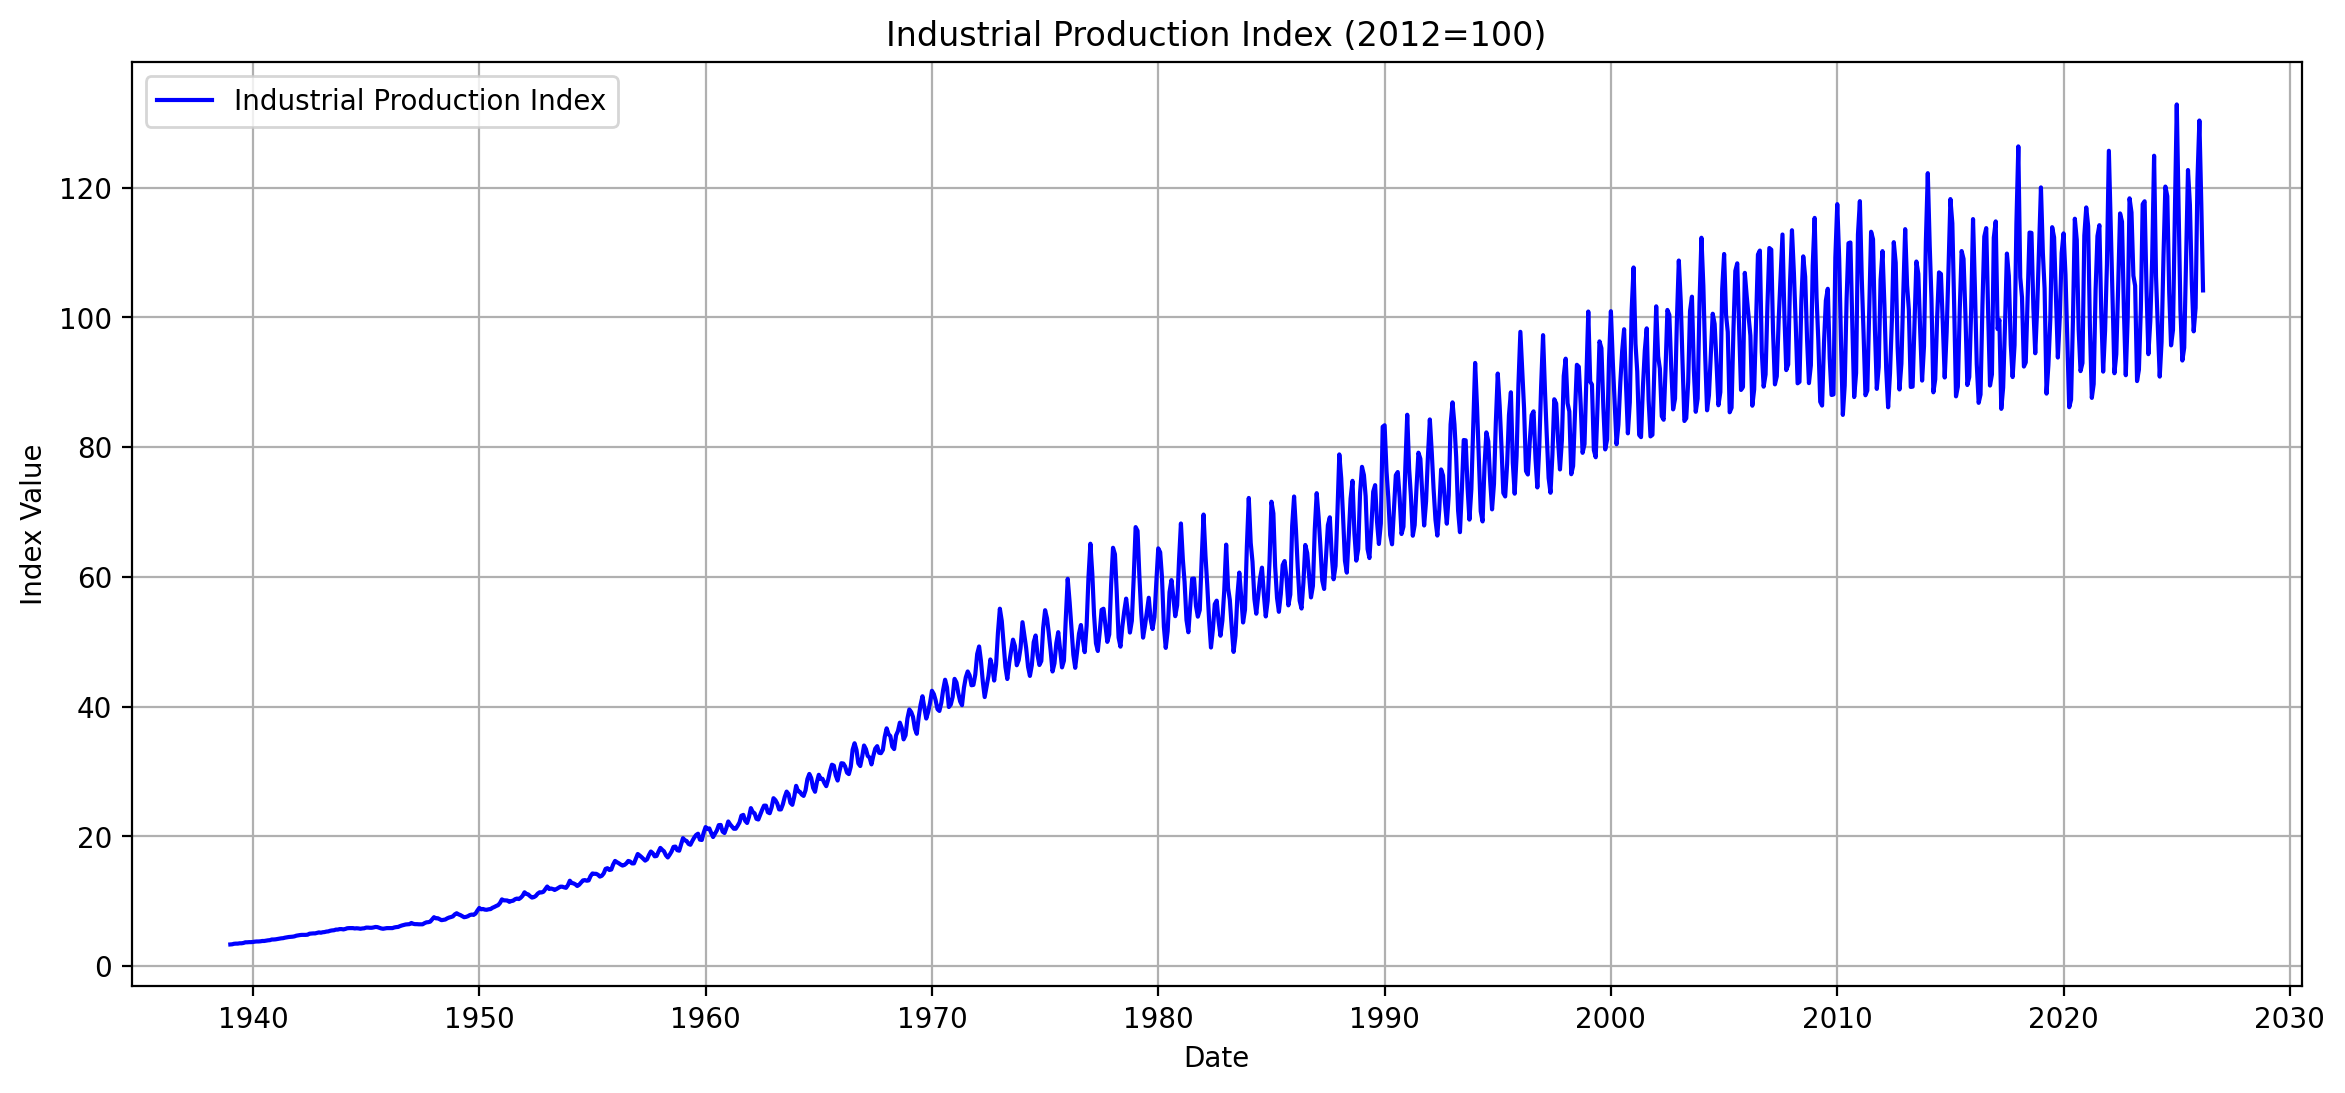

In [16]:
plt.figure(figsize=(14, 6), dpi=200)
plt.title('Industrial Production Index (2012=100)')
plt.plot(df.index, df['IPG2211A2N'], label='Industrial Production Index', color='blue')
plt.xlabel('Date')
plt.ylabel('Index Value')
plt.grid()
plt.legend()
plt.show()

In [4]:
from statsmodels.tsa.arima.model import ARIMA

# Select the time series column
time_series = df['IPG2211A2N']

# Fit an ARMA model (p=1, d=0, q=1)
# Note: ARMA is a special case of ARIMA where d=0 (no differencing)
# The order (p,d,q) represents (AR order, Differencing order, MA order)
model = ARIMA(time_series, order=(2, 0, 2))
model_fit = model.fit()

# Print the model summary
print(model_fit.summary())

c:\Users\Hagen\miniconda3\envs\py312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Hagen\miniconda3\envs\py312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Hagen\miniconda3\envs\py312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Hagen\miniconda3\envs\py312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:             IPG2211A2N   No. Observations:                 1047
Model:                 ARIMA(2, 0, 2)   Log Likelihood               -3053.748
Date:                Tue, 12 May 2026   AIC                           6119.496
Time:                        00:09:39   BIC                           6149.218
Sample:                    01-01-1939   HQIC                          6130.768
                         - 03-01-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         57.6370     50.331      1.145      0.252     -41.009     156.283
ar.L1          1.3447      0.034     39.680      0.000       1.278       1.411
ar.L2         -0.3448      0.034    -10.199      0.0